In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

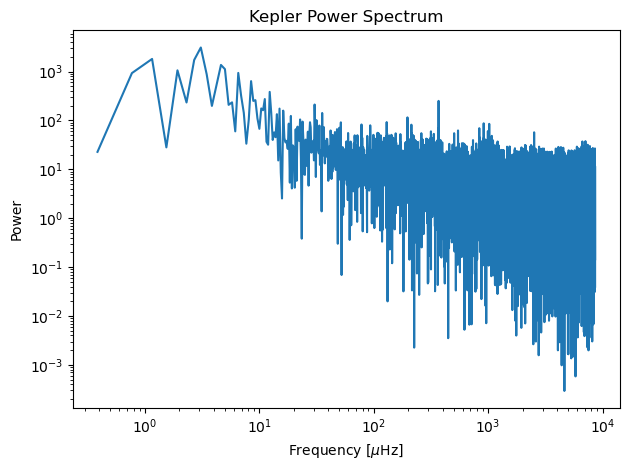

In [2]:
# Path to the .pow file
#pow_file1 = r"C:\Users\douga\Documents\Asteroseismology\GroupStudies202021_KeplerSpectra_Batch1\GroupStudies202021_KeplerSpectra\kplr008006161_kasoc-ts_slc_v1.pow"
pow_file2 = r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\GroupStudies202021_KeplerSpectra_Batch1\GroupStudies202021_KeplerSpectra\kplr008174981_kasoc-ts_slc_v1.pow"
#pow_file3 = r"C:\Users\douga\Documents\Asteroseismology\GroupStudies202021_KeplerSpectra_Batch1\GroupStudies202021_KeplerSpectra\kplr012009504_kasoc-ts_slc_v1.pow"
pow_file1_30 = r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC8006161.pow"
pow_file2_30 = r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC8174981.pow"
pow_file3_30 = r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC12009504.pow"

# Load the data
# Assumes: column 0 = frequency (µHz), column 1 = power
data = np.loadtxt(pow_file2_30)

freq = data[:, 0]
power = data[:, 1]

# Plot
plt.figure()
plt.plot(freq, power)
plt.xlabel("Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.title("Kepler Power Spectrum")
plt.yscale("log")  # standard for asteroseismic power spectra
plt.xscale("log")
#plt.xlim(3000,4000)
plt.tight_layout()
plt.show()

Median Δν bin: 0.385498046875
Std of Δν bin: 0.00019390803680785149
Min power: 0.00029283305048011243
Any NaNs? False
Any infs? False
Δf = 0.385498046875 µHz
Smoothing width (bins): 1556


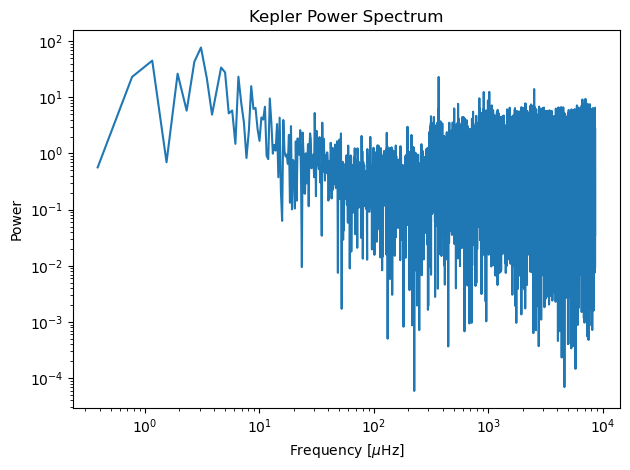

In [3]:
df = np.diff(freq)

print("Median Δν bin:", np.median(df))
print("Std of Δν bin:", np.std(df))

print("Min power:", np.min(power))
print("Any NaNs?", np.any(np.isnan(power)))
print("Any infs?", np.any(np.isinf(power)))
df = np.median(np.diff(freq))  # µHz
print("Δf =", df, "µHz")

smooth_width_muHz = 600
smooth_width_bins = int(smooth_width_muHz / df)
print("Smoothing width (bins):", smooth_width_bins)
background = uniform_filter1d(power, size =smooth_width_bins)

power_flat = power / background
#power_flat /= np.median(power_flat)

plt.figure()
plt.plot(freq, power_flat)
plt.xlabel("Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.title("Kepler Power Spectrum")
plt.yscale("log")  # standard for asteroseismic power spectra
plt.xscale("log")
plt.tight_layout()
plt.show()

In [4]:
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772

def sliding_acf_search(frequency, power_flat, numax_grid,
                       k_width=4.0,
                       lag_frac=(0.8, 1.2)):
    """
    Sliding ACF p-mode search.

    freq, power : full spectrum
    numax_grid  : trial νmax values (μHz)
    k_width     : window width in units of Δν
    lag_frac    : fraction of Δν to search for ACF peak
    """

    acf_strength = []

    for nu_c in tqdm(numax_grid):

        # Δν estimate
        dnu = delta_nu_from_numax(nu_c)

        # Window size
        W = k_width * dnu

        mask = (freq > nu_c - W/2) & (freq < nu_c + W/2)
        if mask.sum() < 20:
            acf_strength.append(0.0)
            continue

        # Local, whitened spectrum
        p = power_flat[mask]
        p = p / np.median(p)

        # Autocorrelation
        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size//2:]

        # Lag axis
        df = freq[1] - freq[0]
        lag = np.arange(acf.size) * df

        # Measure strength near Δν
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)
        strength = np.max(acf[lag_mask])

        acf_strength.append(strength)

    return np.array(acf_strength)


In [5]:
numax_grid = np.linspace(50, 5000, 100)

acf_power = sliding_acf_search(
    freq,
    power_flat,
    numax_grid,
    k_width=4.0
)

numax_est = numax_grid[np.argmax(acf_power)]


100%|██████████| 100/100 [00:00<00:00, 1755.83it/s]


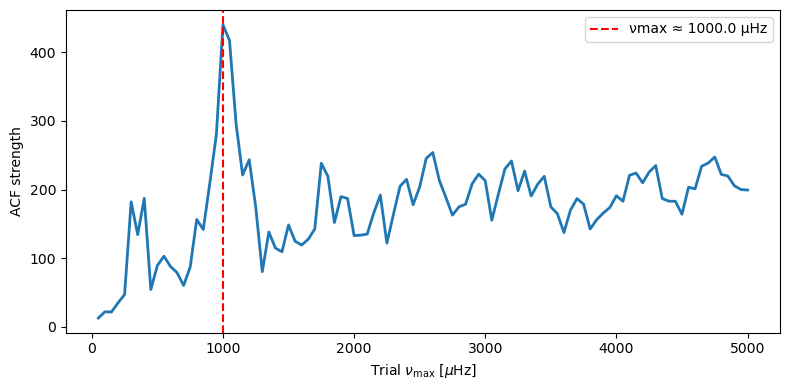

In [6]:
plt.figure(figsize=(8,4))
plt.plot(numax_grid, acf_power, lw=2)
plt.axvline(numax_est, color="r", ls="--", label=f"νmax ≈ {numax_est:.1f} μHz")
plt.xlabel(r"Trial $\nu_{\max}$ [$\mu$Hz]")
plt.ylabel("ACF strength")
plt.legend()
plt.tight_layout()
plt.show()

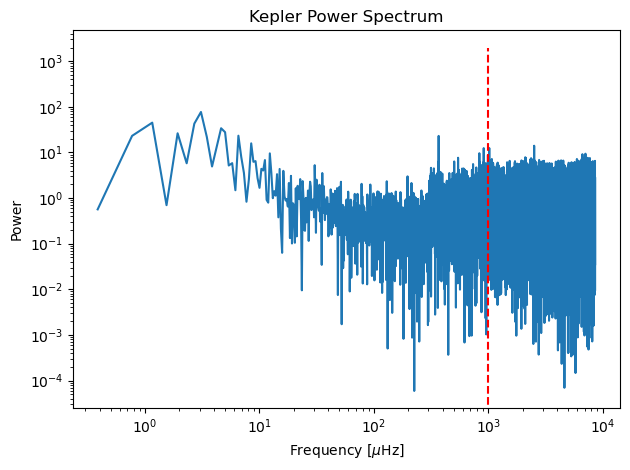

In [7]:
plt.figure()
plt.plot(freq, power_flat)
plt.xlabel("Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.vlines(numax_est, 0, 2000, color = "r", linestyle ="dashed")
plt.title("Kepler Power Spectrum")
plt.yscale("log")  # standard for asteroseismic power spectra
plt.xscale("log")
plt.tight_layout()
plt.show()

In [8]:
delta_nu_est = delta_nu_from_numax(numax_est)
# width = 4* delta_nu_est
# mask = (freq >= numax_est - width) & (freq <= numax_est + width)
# freq_window = freq[mask]
# power_window = power[mask]

# acf_full = np.correlate(power_window, power_window, mode="full")
# N = len(power_window)
# acf = acf_full[N-1:]
# lags_bins = np.arange(len(acf))
# lags_muHz = lags_bins * df
# acf /= acf[0]
# lag_min = 20.0
# lag_max = 200.0

# mask_lag = (lags_muHz >= lag_min) & (lags_muHz <= lag_max)

# lags_plot = lags_muHz[mask_lag]
# acf_plot = acf[mask_lag]

# plt.figure()
# plt.plot(lags_plot, acf_plot, lw=1)
# plt.axhline(0.0, color="k", ls="--", lw=0.8)
# plt.xlabel(r"Lag [$\mu$Hz]")
# plt.ylabel("Normalised ACF")
# plt.title("Autocorrelation of flattened power spectrum")
# plt.tight_layout()
# plt.show()


In [9]:
import numpy as np

def get_mode_envelope_mask(freq, power, delta_nu_est):
    """
    Calculates a frequency mask for solar-like oscillations based on delta_nu.
    
    Parameters:
    - frequency (array): The frequency array (uHz).
    - power (array): The power spectrum array.
    - delta_nu (float): The large frequency separation (uHz).
    
    Returns:
    - freq_sel, power_sel: The masked arrays.
    """
    
    # 1. Estimate Nu Max from Delta Nu
    # Relation: delta_nu ~= 0.263 * nu_max^0.772 (Huber et al. 2011)
    # Rearranged: nu_max = (delta_nu / 0.263) ** (1 / 0.772)
    nu_max = numax_est                                     #(delta_nu_est / 0.263) ** (1.295) 

    # 2. Estimate the Width of the Envelope (FWHM)
    # Relation: FWHM_env ~= 0.66 * nu_max^0.88 (Mosser et al. 2012)
    # Note: We use a slightly generous factor to ensure we catch the "tails"
    fwhm_env = 0.66 * (nu_max ** 0.88)
    
    # 3. Define the standard deviation (sigma) of the envelope
    # FWHM = 2.355 * sigma
    sigma_env = fwhm_env / 2.355
    
    # 4. Define the Cutoffs
    # We want a range that covers virtually ALL modes. 
    # +/- 3 sigma covers 99.7% of the power envelope.
    # We also clamp fmin to 0 to prevent negative frequency errors.
    lower_bound = nu_max - (4.0 * sigma_env)
    upper_bound = nu_max + (4.0 * sigma_env)
    
    fmin = max(0, lower_bound)
    fmax = upper_bound

    # --- YOUR REQUESTED SNIPPET ---
    mask = (freq >= fmin) & (freq <= fmax)

    freq_sel = freq[mask]
    power_sel = power[mask]
    
    return freq_sel, power_sel, fmin, fmax, nu_max

# Example Usage:
freq_sel, power_sel, fmin, fmax, nu_max = get_mode_envelope_mask(freq, power, delta_nu_est)

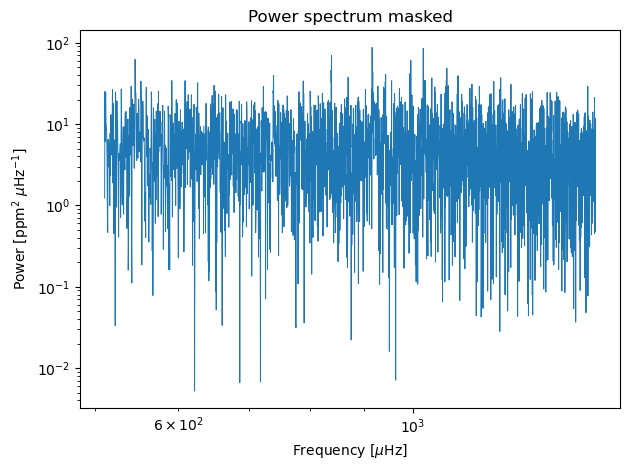

In [10]:
plt.figure()
plt.plot(freq_sel, power_sel, lw=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Frequency [$\mu$Hz]")
plt.ylabel(r"Power [ppm$^2$ $\mu$Hz$^{-1}$]")
plt.title("Power spectrum masked")

plt.tight_layout()
plt.show()

In [11]:
df = np.diff(freq_sel)

print("Median Δν bin:", np.median(df))
print("Std of Δν bin:", np.std(df))
print("Min power:", np.min(power_sel))
print("Any NaNs?", np.any(np.isnan(power_sel)))
print("Any infs?", np.any(np.isinf(power_sel)))
df = np.median(np.diff(freq_sel))  # µHz
print("Δf =", df, "µHz")


Median Δν bin: 0.385498046875
Std of Δν bin: 2.7690829590400577e-05
Min power: 0.005239528138190508
Any NaNs? False
Any infs? False
Δf = 0.385498046875 µHz


Smoothing width (bins): 1556


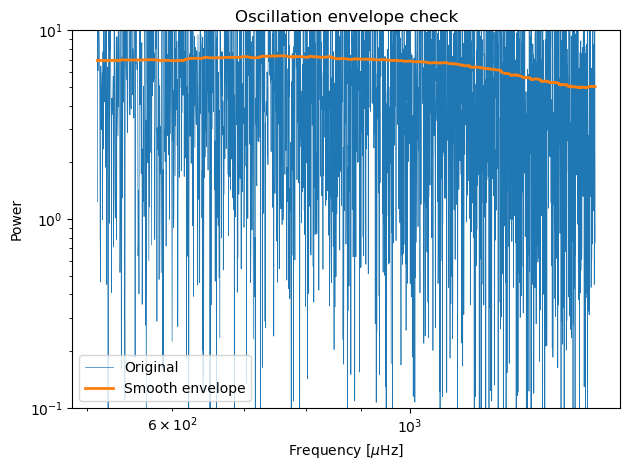

In [12]:
smooth_width_muHz = 600.0
smooth_width_bins = int(smooth_width_muHz / df)

print("Smoothing width (bins):", smooth_width_bins)

from scipy.ndimage import uniform_filter1d

background = uniform_filter1d(power_sel, size=smooth_width_bins)

plt.figure()
plt.plot(freq_sel, power_sel, lw=0.5, label="Original")
plt.plot(freq_sel, background, lw=2, label="Smooth envelope")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.ylim(0.1,10)
plt.legend()
plt.title("Oscillation envelope check")
plt.tight_layout()
plt.show()

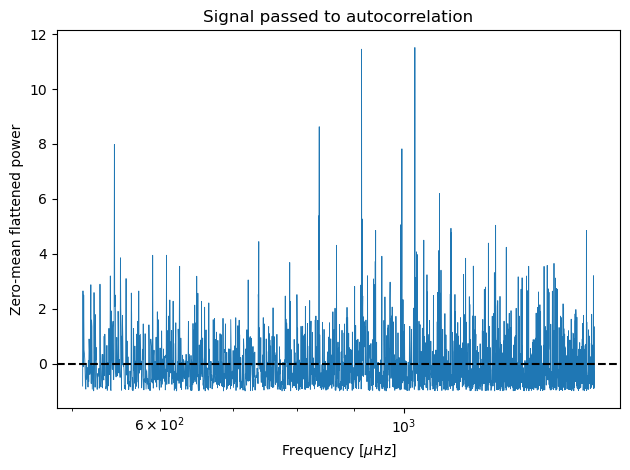

2.0988855920444078e-17 1.0790979487139036


In [13]:
power_flat = power_sel / background

signal = power_flat - np.mean(power_flat)
plt.figure()
plt.plot(freq_sel, signal, lw=0.6)
plt.axhline(0.0, color="k", ls="--")
plt.xscale("log")
plt.xlabel(r"Frequency [$\mu$Hz]")
plt.ylabel("Zero-mean flattened power")
plt.title("Signal passed to autocorrelation")
plt.tight_layout()
plt.show()
print(np.mean(signal), np.std(signal))

In [14]:
acf_full = np.correlate(signal, signal, mode="full")


In [15]:
N = len(signal)
acf = acf_full[N-1:]
lags_bins = np.arange(len(acf))
lags_muHz = lags_bins * df
acf /= acf[0]
lag_min = 20.0
lag_max = 400.0

mask_lag = (lags_muHz >= lag_min) & (lags_muHz <= lag_max)

lags_plot = lags_muHz[mask_lag]
acf_plot = acf[mask_lag]

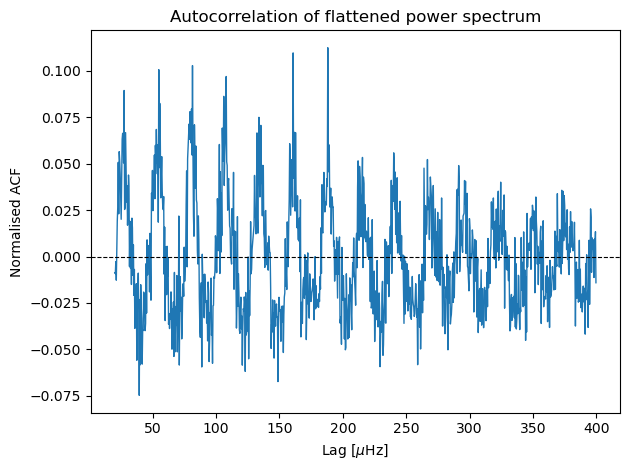

delta_nu: 188.123046875


In [16]:
plt.figure()
plt.plot(lags_plot, acf_plot, lw=1)
plt.axhline(0.0, color="k", ls="--", lw=0.8)
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalised ACF")
plt.title("Autocorrelation of flattened power spectrum")
plt.tight_layout()
plt.show()
max_idx = np.argmax(acf_plot)

# 2. Get the coordinates
delta_nu = lags_plot[max_idx]
y_max = acf_plot[max_idx]

print(f"delta_nu: {delta_nu}")

In [17]:
import numpy as np

def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.2):
    """
    Mask ACF around delta_nu, excluding delta_nu/2 and 3*delta_nu/2.

    Parameters
    ----------
    lags : array
        Lag values (µHz)
    acf : array
        ACF values
    delta_nu_est : float
        Estimated large separation (µHz)
    window_frac : float
        Fractional half-width of the delta_nu window (e.g. 0.2 = ±20%)

    Returns
    -------
    lags_masked, acf_masked
    """

    # Central window around delta_nu
    main_lo = delta_nu_est * (1 - window_frac)
    main_hi = delta_nu_est * (1 + window_frac)

    # Exclusion windows
    half_lo = 0.5 * delta_nu_est * (1 - window_frac)
    half_hi = 0.5 * delta_nu_est * (1 + window_frac)

    three_half_lo = 1.5 * delta_nu_est * (1 - window_frac)
    three_half_hi = 1.5 * delta_nu_est * (1 + window_frac)

    mask = (
        (lags > main_lo) & (lags < main_hi) &
        ~((lags > half_lo) & (lags < half_hi)) &
        ~((lags > three_half_lo) & (lags < three_half_hi))
    )

    return lags[mask], acf[mask]


In [18]:
lags_fit, acf_fit = mask_acf_for_deltanu(
    lags_plot,
    acf_plot,
    delta_nu_est,   # example
    window_frac=0.15
)


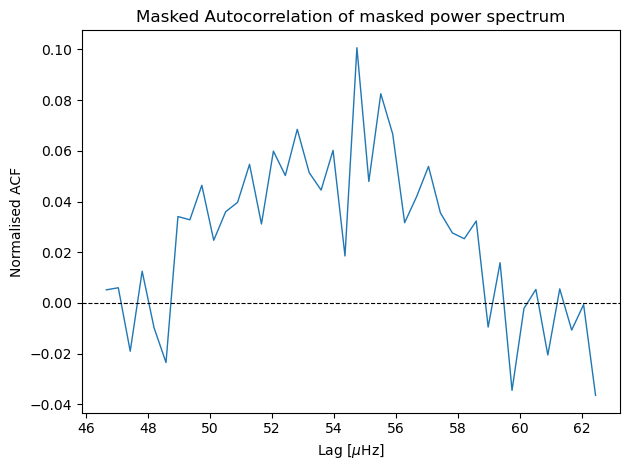

In [19]:
plt.figure()
plt.plot(lags_fit, acf_fit, lw=1)
plt.axhline(0.0, color="k", ls="--", lw=0.8)
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalised ACF")
plt.title("Masked Autocorrelation of masked power spectrum")
plt.tight_layout()
plt.show()
max_idx = np.argmax(acf_plot)

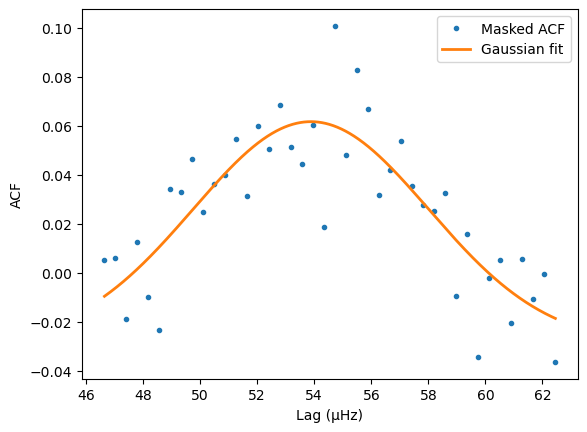

Δν = 53.88 ± 0.28 µHz


In [20]:
def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c
from scipy.optimize import curve_fit

p0 = [
    np.max(acf_fit),          # A
    delta_nu_est,             # mu
    0.05 * delta_nu_est,      # sigma
    0.0                        # offset
]

popt, pcov = curve_fit(gaussian, lags_fit, acf_fit, p0=p0)
lags_smooth = np.linspace(lags_fit.min(), lags_fit.max(), 1000)
acf_model = gaussian(lags_smooth, *popt)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(lags_fit, acf_fit, ".", label="Masked ACF")
plt.plot(lags_smooth, acf_model, "-", lw=2, label="Gaussian fit")
plt.xlabel("Lag (µHz)")
plt.ylabel("ACF")
plt.legend()
plt.show()
delta_nu_fit = popt[1]
delta_nu_err = np.sqrt(pcov[1, 1])

print(f"Δν = {delta_nu_fit:.2f} ± {delta_nu_err:.2f} µHz")
